In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Make Two Motions Modles
    # For Each Motion Model,
        # Use TOA position measurements, track with EKF

        # Use TDOA position measurements, track with EKF, UKF, PMF or Particle Filter for the two motion models
class KalmanBase:
    def __init__(self, state, P, Q, R):
        self.state = state
        self.P = P
        self.Q = Q
        self.R = R

    def predict(self, dt):
        raise NotImplementedError("predict must be implemented by subclass")

    def update(self, dt):
        raise NotImplementedError("update must be implemented by subclass")

    def get_state(self):
        return self.state

class EKFBase(KalmanBase):
    def __init__(self, state, P, Q, R, I):
        self.I = I
        super().__init__(state, P, Q, R)

    def predict(self, dt):
        F = self.process_model_jacobian(dt)
        self.state = self.process_model(dt)
        self.P = F @ self.P @ F.T + F @ self.Q @ F.T
        return

    def update(self, measurement):
        H = self.measurement_model_jacobian()
        K = self.P @ H.T @ np.linalg.inv(H @ self.P @ H.T + self.R)
        innovation = measurement - self.measurement_model()
        self.state = self.state + K @ innovation
        self.P = (self.I - K @ H) @ self.P @ (self.I - K @ H).T + K @ self.R @ K.T
        return

    def process_model_jacobian(self, dt):
        raise NotImplementedError("process_model_jacobian must be implemented by subclass")

    def process_model(self, dt):
        raise NotImplementedError("process_model must be implemented by subclass")

    def measurement_model_jacobian(self):
        raise NotImplementedError("measurement_model_jacobian must be implemented by subclass")

    def measurement_model(self):
        raise NotImplementedError("measurement_model must be implemented by subclass")


class EKF2Base(KalmanBase):
    def __init__(self, state, P, Q, R):
        super().__init__(state, P, Q, R)

    def predict(self, dt):
        Fp = self.process_model_jacobian(dt)
        Fpp = self.process_model_hessian(dt)
        self.state = self.process_model(dt) + 0.5 * np.einsum('kij,ij->k', Fpp, self.P).reshape(self.state.shape) # tr(Fpp[k] @ P)
        M = np.einsum('kij,jl->kil', Fpp, self.P)  # M[k] = Fpp[k] @ P
        dP = 0.5 * np.einsum('kij,lji->kl', M, M)  # dP[k,l] = 0.5 * tr(M[k] @ M[l])
        self.P = Fp @ self.P @ Fp.T + Fp @ self.Q @ Fp.T + dP
        return

    def update(self, measurement):
        Hp = self.measurement_model_jacobian()
        Hpp = self.measurement_model_hessian()

        M = np.einsum('kij,jl->kil', Hpp, self.P)  # M[k] = Hpp[k] @ P
        dH = 0.5 * np.einsum('kij,lji->kl', M, M)  # dH[k,l] = 0.5 * tr(M[k] @ M[l])
        S = Hp @ self.P @ Hp.T + self.R + dH
        K = self.P @ Hp.T @ np.linalg.inv(S)

        pred_meas = self.measurement_model()
        innovation = measurement - pred_meas - 0.5 * np.einsum('kij,ij->k', Hpp, self.P).reshape(pred_meas.shape) # tr(Hpp[k] @ P)
        self.state = self.state + K @ innovation
        
        self.P = self.P - self.P @ Hp.T @ np.linalg.inv(S) @ Hp @ self.P
        return

    def process_model_jacobian(self, dt):
        raise NotImplementedError("process_model_jacobian must be implemented by subclass")

    def process_model_hessian(self, dt):
        raise NotImplementedError("process_model_hessian must be implemented by subclass")

    def process_model(self, dt):
        raise NotImplementedError("process_model must be implemented by subclass")

    def measurement_model_jacobian(self):
        raise NotImplementedError("measurement_model_jacobian must be implemented by subclass")
    
    def measurement_model_hessian(self):
        raise NotImplementedError("measurement_model_hessian must be implemented by subclass")

    def measurement_model(self):
        raise NotImplementedError("measurement_model must be implemented by subclass")


class UKFBase(KalmanBase):
    def __init__(self, state, P, Q, R):
        self.alpha = 1e-3
        self.beta = 2
        self.kappa = 0
        super().__init__(state, P, Q, R)

    def predict(self, dt):
        state_aug = np.concatenate((self.state, np.zeros_like(self.state))) # augment state vector
        cov_aug = np.block([[self.P, np.zeros_like(self.P)], [np.zeros_like(self.Q), self.Q]]) # augment covariance matrix
        
        S, Wm, Wc = self.sigma_points(state_aug, cov_aug)# generate sigma points and weights from state and P

        # apply process model to each sigma
        # apply weights to get predicted state and P and combine with Q

        state_aug = np.zeros_like(state_aug)
        cov_aug = np.zeros_like(cov_aug)

        S_est = [self.process_model(s, dt) for s in S]

        for s, wm in zip(S_est, Wm):
            state_aug += wm * s

        for s, wc in zip(S_est, Wc):
            cov_aug += wc * np.outer(s - state_aug, s - state_aug)

        self.state = state_aug[:self.state.shape[0]]
        self.P = cov_aug[:self.P.shape[0], :self.P.shape[1]]

        return


    def update(self, measurement):

        # generate sigma points
        S, Wm, Wc = self.sigma_points(self.state, self.P)
        Y = [self.measurement_model(s) for s in S]

        Y_est = np.zeros_like(measurement)
        for y, wm in zip(Y, Wm):
            Y_est += wm * y

        P_xy = np.zeros((self.state.shape[0], measurement.shape[0]))
        for (s, y, wc) in zip(S, Y, Wc):
            P_xy += wc * np.outer(s - self.state, y - Y_est)

        P_yy = np.zeros_like(self.R)
        for (y, wc) in zip(Y, Wc):
            P_yy += wc * np.outer(y - Y_est, y - Y_est)
        P_yy += self.R

        self.state += P_xy @ np.linalg.inv(P_yy) @ (measurement - Y_est)
        self.P -= P_xy @ np.linalg.inv(P_yy) @ P_xy.T
        return

    def _lambda(self, n):
        return self.alpha**2 * (n + self.kappa) - n

    def sigma_points(self, state_aug, cov_aug):
        n = state_aug.shape[0]
        X = np.zeros((2 * n + 1, n))
        Wm = np.zeros((2 * n + 1))
        Wc = np.zeros((2 * n + 1))
        l = self._lambda(n)
        L = np.linalg.cholesky(cov_aug)

        X[0] = state_aug
        Wm[0] = l / (n + l)
        Wc[0] = l / (n + l) + (1 - self.alpha**2 + self.beta)

        for i in range(1,n+1): # 1 to n
            # each sigma point lies in an orthogonal direction on the error ellipse
            X[i] = state_aug + np.sqrt(n + l) * L[:, i-1]
            Wm[i] = 1 / (2 * (n + l))
            Wc[i] = 1 / (2 * (n + l))

        for i in range(n+1,2*n+1): # n+1 to 2*n
            # sample in the opposite direction to capture negative deviations, the ellipse is two sided
            X[i] = state_aug - np.sqrt(n + l) * L[:, i-n-1]
            Wm[i] = 1 / (2 * (n + l))
            Wc[i] = 1 / (2 * (n + l))

        return X, Wm, Wc
    
    def process_model(self, state_aug, dt) -> np.array:
        raise NotImplementedError("process_model must be implemented on augmented space by subclass")
    
    def measurement_model(self, state):
        raise NotImplementedError("measurement_model must be implemented by subclass")
    
    


# Motion Model 1
## Coordinated Turn with Velocity and Rate (CTVR)

- position (x,y)
- velocity (v)
- heading (theta) , define y direction as heading 0
- yaw rate (omega)

state = [x, y, v, theta, omega]

#### state update
    state[n+1] = f(x[n], y[n], v[n], theta[n], omega[n]) + vk 

v[n+1] = v[n]

omega[n+1] = omega[n]

theta[n+1] = theta[n] + omega[n]*dt


##### lets find the circle we are travelling along!

 we start at x[n], y[n]

 circle radius is...

 circumference = time to rotate 2pi radians * linear velocity!

omega rad/s  -> 1/omega (s/rad) * 2pi (rad) = 2pi/omega = time to rotate 2pi

2pi*V/omega = Circumference = 2pi R -> R = V/omega





x[n+1] = x[n] + v[n] * sin(0.5*(theta[n+1] - theta[n])) * dt 

y[n+1] = x[n] + v[n] * cos(0.5*(theta[n+1] - theta[n])) * dt


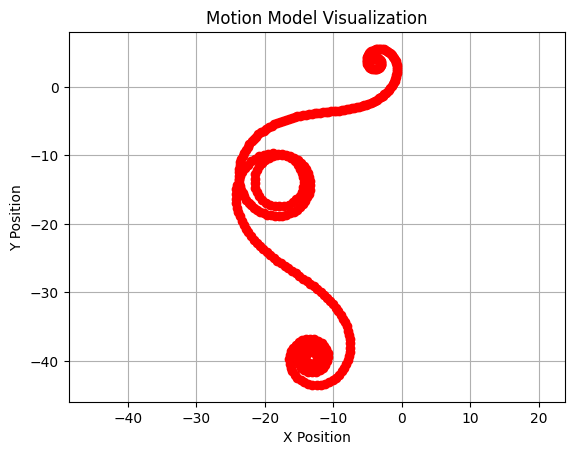

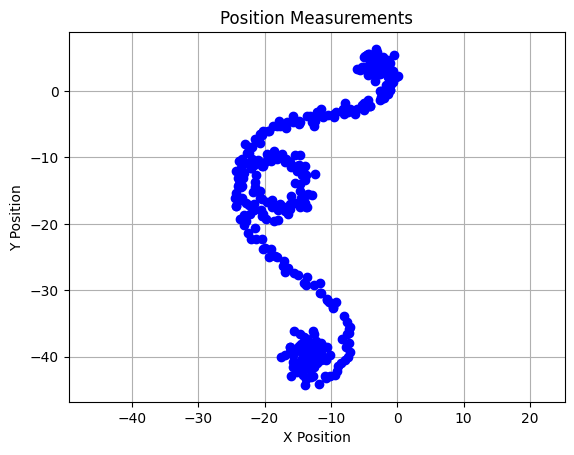

In [12]:
N = 400
DT = 0.1
NOISE = 1.0

class state:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def time_update(self, dt):
        x = self.pos[0]
        y = self.pos[1]

        if abs(self.omega) < 1e-6:
            x += self.vel*np.sin(self.theta)*dt
            y += self.vel*np.cos(self.theta)*dt
        else:    
            x += (self.vel / self.omega)*(np.cos(self.theta) - np.cos(self.theta + self.omega*dt))
            y += -(self.vel / self.omega)*(np.sin(self.theta) - np.sin(self.theta + self.omega*dt))
            
        self.theta += self.omega*dt
        self.pos = np.array([x, y])
        return

    def input_update(self, vel, omega):
        self.vel = vel
        self.omega = omega
        pass



state = state(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0)


plt.figure()
plt.plot(state.pos[0], state.pos[1], 'ro')
pos_meas = [state.pos + 1*np.random.normal(0, 0.5, size=2)]
pos_true = [state.pos.copy()]

for i in range(N):

    state.time_update(DT)

    if i < 200:
        dv = 0.03
        dw = -0.02
    else:
        dv = -0.01
        dw = 0.04
    state.input_update(vel=state.vel+dv, omega=state.omega+dw)

    plt.plot(state.pos[0], state.pos[1], 'ro')

    pos_meas.append(state.pos + NOISE*np.random.normal(0, 0.5, size=2))
    pos_true.append(state.pos.copy())


plt.title('Motion Model Visualization')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.axis('equal')
plt.show()


plt.figure()
plt.plot([pos[0] for pos in pos_meas], [pos[1] for pos in pos_meas], 'bo', label='Position Measurements')
plt.title('Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.axis('equal')
plt.show()


# Tracking Test of Motion Model 1

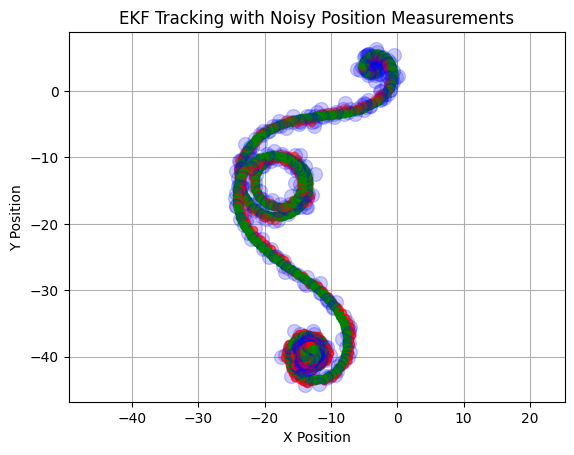

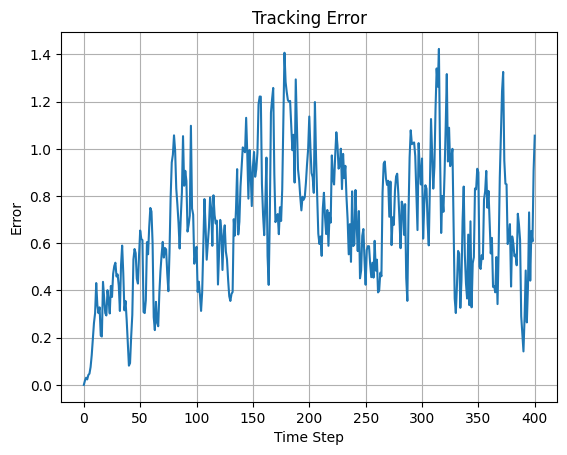

2 sigma (95.45%): 1.1854
3 sigma (99.73%): 1.4016


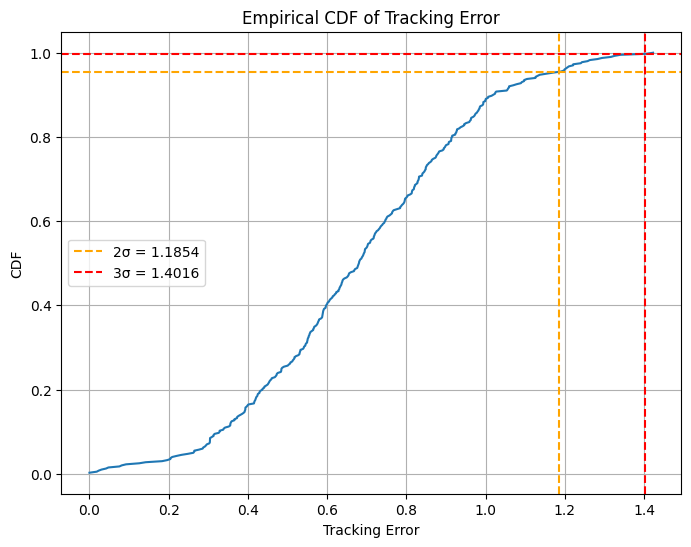

In [13]:
# Coordinated Turn with Velocity and Rate (CTVR) EKF
# constant linear and angular velocity
class CTVR_EKF(EKFBase):
    def __init__(self, state):
        P = np.eye(5) * 1e-2  # State covariance matrix
        Q = np.eye(5) * 1e-2  # Process noise covariance
        R = np.eye(2) * 0.5  # Measurement noise covariance
        I = np.eye(5)
        super().__init__(state, P, Q, R, I)

    def process_model_jacobian(self, dt):
        x, y, v, theta, omega = self.state
        F = np.eye(5)

        # linear motion case
        if abs(omega) < 1e-6:
            F[0,2] = np.sin(theta)*dt
            F[0,3] = v*np.cos(theta)*dt
            F[1,2] = np.cos(theta)*dt
            F[1,3] = -v*np.sin(theta)*dt
            self.F = F

        # non linear motion case
        else:
            theta_new = theta + omega*dt

            # ∂X_new/∂V = (1/W)[cos(T) - cos(T+W*dt)]
            F[0,2] = (1/omega) * (np.cos(theta) - np.cos(theta_new))

            # ∂X_new/∂T = (V/W)[-sin(T) + sin(T+W*dt)]
            F[0,3] = (v/omega) * (-np.sin(theta) + np.sin(theta_new))

            # ∂X_new/∂W = -(V/W²)[cos(T) - cos(T+W*dt)] + (V/W)*sin(T+W*dt)*dt
            F[0,4] = -(v/omega**2) * (np.cos(theta) - np.cos(theta_new)) + \
                    (v/omega) * np.sin(theta_new) * dt

            # ∂Y_new/∂V = (1/W)[-sin(T) + sin(T+W*dt)]
            F[1,2] = (1/omega) * (-np.sin(theta) + np.sin(theta_new))

            # ∂Y_new/∂T = (V/W)[-cos(T) + cos(T+W*dt)]
            F[1,3] = (v/omega) * (-np.cos(theta) + np.cos(theta_new))

            # ∂Y_new/∂W = -(V/W²)[-sin(T) + sin(T+W*dt)] + (V/W)*cos(T+W*dt)*dt
            F[1,4] = -(v/omega**2) * (-np.sin(theta) + np.sin(theta_new)) + \
                    (v/omega) * np.cos(theta_new) * dt

            # ∂T_new/∂W = dt
            F[3,4] = dt

        return F

    def process_model(self, dt):
        x, y, v, theta, omega = self.state
    
        # linear motion case (omega ~ 0)
        if abs(omega) < 1e-6:
            x += v*np.sin(theta)*dt
            y += v*np.cos(theta)*dt
        
        # non linear motion case (|omega| > 0)
        else:
            x += (v / omega)*(np.cos(theta) - np.cos(theta+omega*dt))
            y += -(v / omega)*(np.sin(theta) - np.sin(theta+omega*dt))

        theta += omega*dt
        state = np.array([x, y, v, theta, omega])
        return state

    def measurement_model_jacobian(self):
        H = np.array([[ 1,  0,  0,  0,  0 ],
                      [ 0,  1,  0,  0,  0 ]])
        return H
    
    def measurement_model(self):
        x, y, v, theta, omega = self.state
        return np.array([x, y])

class State:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def vec(self):
        return np.array([self.pos[0], self.pos[1], self.vel, self.theta, self.omega])
    
state = State(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0).vec()

ekf = CTVR_EKF(state)

plt.figure()
plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):

    ekf.predict(DT)

    # measure
    measurement = pos_meas[i]

    ekf.update(measurement)
    state = ekf.get_state()


    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('EKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()


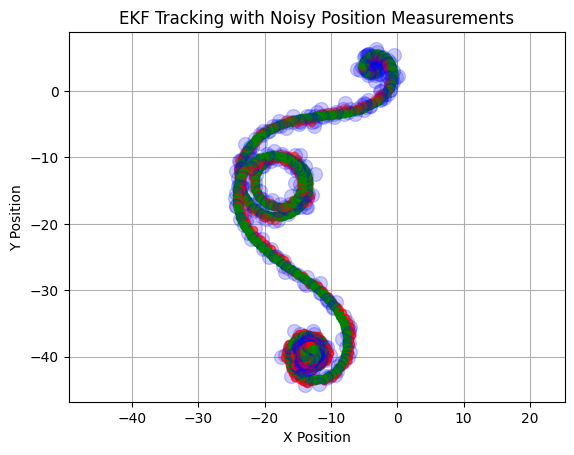

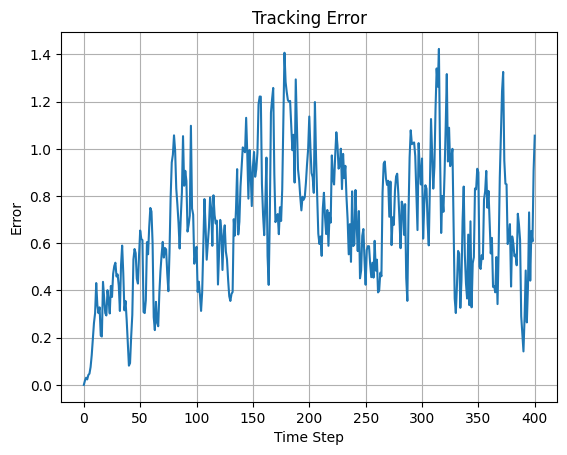

2 sigma (95.45%): 1.1854
3 sigma (99.73%): 1.4016


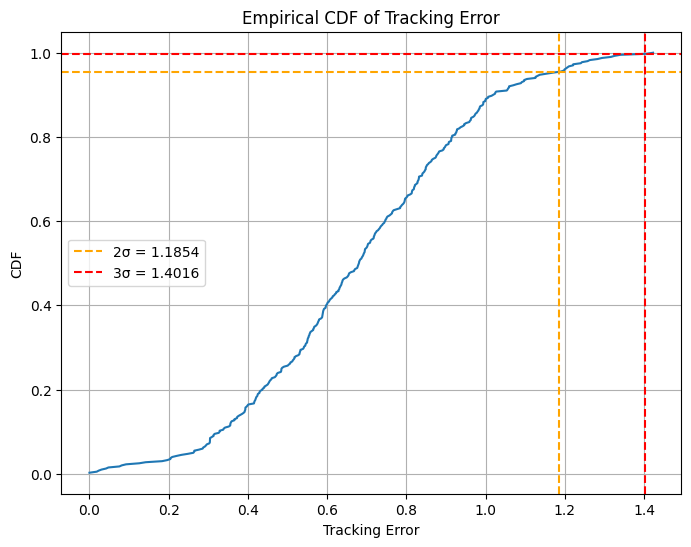

In [14]:
# Coordinated Turn with Velocity and Rate (CTVR) EKF
# constant linear and angular velocity
class CTVR_UKF(UKFBase):
    def __init__(self, state):
        P = np.eye(5) * 1e-2  # State covariance matrix
        Q = np.eye(5) * 1e-2  # Process noise covariance
        R = np.eye(2) * 0.5  # Measurement noise covariance
        I = np.eye(5)
        super().__init__(state, P, Q, R, I)


    def process_model(self, dt):
        x, y, v, theta, omega = self.state
    
        # linear motion case (omega ~ 0)
        if abs(omega) < 1e-6:
            x += v*np.sin(theta)*dt
            y += v*np.cos(theta)*dt
        
        # non linear motion case (|omega| > 0)
        else:
            x += (v / omega)*(np.cos(theta) - np.cos(theta+omega*dt))
            y += -(v / omega)*(np.sin(theta) - np.sin(theta+omega*dt))

        theta += omega*dt
        state = np.array([x, y, v, theta, omega])
        return state

    def measurement_model_jacobian(self):
        H = np.array([[ 1,  0,  0,  0,  0 ],
                      [ 0,  1,  0,  0,  0 ]])
        return H

    def measurement_model_hessian(self):
        return
    
    def measurement_model(self):
        x, y, v, theta, omega = self.state
        return np.array([x, y])

class State:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def vec(self):
        return np.array([self.pos[0], self.pos[1], self.vel, self.theta, self.omega])
    
state = State(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0).vec()

ekf = CTVR_EKF(state)

plt.figure()
plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):

    ekf.predict(DT)

    # measure
    measurement = pos_meas[i]

    ekf.update(measurement)
    state = ekf.get_state()


    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('EKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()


# Motion Model 2
## Singer motion model

- position (x,y)
- velocity (dx/dt, dy/dy)
- acceleration (d^2x/dt^2, d^2y/dt^2)

state = [x, vx, ax, y, vy, ay]

#### state update
    state^[n+1] = Fn @ stage[n]

F = 
[[ 1  T  (αT−1+e^(−αT)) / α^2 ]
 [ 0  1     (1−e^(−αT)) / α   ]
 [ 0  0          e^(−αT)      ]]


#### measurement model

Y = [dt_s1, dt_s2, ..., dt_sn]

Y[n] = h(x[n], y[n]) + e_n

h_i(pos[n]) = (1/c) * norm(||pos - s_i|| - ||pos - s_ref||)

In [15]:
# Coordinated Turn with Velocity and Rate (CTVR) EKF
# constant linear and angular velocity
class SINGER_EKF(EKFBase):
    def __init__(self, state, R, tau):
        P = np.eye(6) * 1e-2  # State covariance matrix
        Q = np.eye(6) * 1e-2  # Process noise covariance
        # R = np.eye(3) * 0.5  # Measurement noise covariance
        I = np.eye(6)
        self.tau = tau
        super().__init__(state, P, Q, R, I)

    def process_model_jacobian(self, dt):
        a = 1/self.tau
        F = [[ 1,   dt, (a*dt - 1 + np.exp(-a*dt))/(a**2), 0,   0,                    0                 ],
             [ 0,    1,        (1 - np.exp(-a*dt))/a     , 0,   0,                    0                 ],
             [ 0,    0,            np.exp(-a*dt)         , 0,   0,                    0                 ],
             [ 0,    0,            0                     , 1,   dt,   (a*dt - 1 + np.exp(-a*dt))/(a**2) ],
             [ 0,    0,            0                     , 0,   1,           (1 - np.exp(-a*dt))/a      ],
             [ 0,    0,            0                     , 0,   0,               np.exp(-a*dt)          ]]

        return np.array(F)

    def process_model(self, dt):
        x, _, _, y, _, _ = self.state
        F = self.process_model_jacobian(dt)
        state = F @ self.state
        return state

    def measurement_model_jacobian(self):
        x = float(self.state[0, 0])  # scalar
        y = float(self.state[3, 0])  # scalar (state = [x, vx, ax, y, vy, ay]^T)

        r_1 = np.linalg.norm(np.array([x, y]) - self.s_1)
        r_2 = np.linalg.norm(np.array([x, y]) - self.s_2)
        r_3 = np.linalg.norm(np.array([x, y]) - self.s_3)
        r_ref = np.linalg.norm(np.array([x, y]) - self.s_ref)

        H = np.array([
            [(x - self.s_1[0]) / r_1 - (x - self.s_ref[0]) / r_ref, 0.0, 0.0,
             (y - self.s_1[1]) / r_1 - (y - self.s_ref[1]) / r_ref, 0.0, 0.0],
            [(x - self.s_2[0]) / r_2 - (x - self.s_ref[0]) / r_ref, 0.0, 0.0,
             (y - self.s_2[1]) / r_2 - (y - self.s_ref[1]) / r_ref, 0.0, 0.0],
            [(x - self.s_3[0]) / r_3 - (x - self.s_ref[0]) / r_ref, 0.0, 0.0,
             (y - self.s_3[1]) / r_3 - (y - self.s_ref[1]) / r_ref, 0.0, 0.0],
        ], dtype=float)
        H = H / self.c
        return H
    
    def measurement_model(self):
        s = np.asarray(self.state, dtype=float).reshape(-1)
        x, y = s[0], s[3]
        pos = np.array([x, y], dtype=float)

        d_ref = np.linalg.norm(pos - np.asarray(self.s_ref, dtype=float))
        dt_s1 = (1.0 / self.c) * (np.linalg.norm(pos - np.asarray(self.s_1, dtype=float)) - d_ref)
        dt_s2 = (1.0 / self.c) * (np.linalg.norm(pos - np.asarray(self.s_2, dtype=float)) - d_ref)
        dt_s3 = (1.0 / self.c) * (np.linalg.norm(pos - np.asarray(self.s_3, dtype=float)) - d_ref)

        return np.array([[dt_s1], [dt_s2], [dt_s3]], dtype=float)

class State:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def vec(self):
        return np.array([self.pos[0], self.pos[1], self.vel, self.theta, self.omega])
    

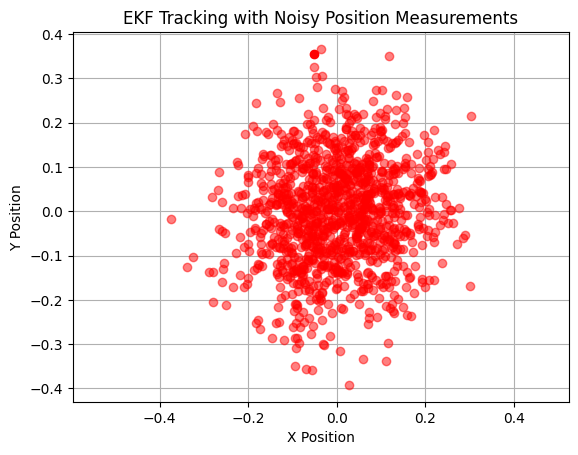

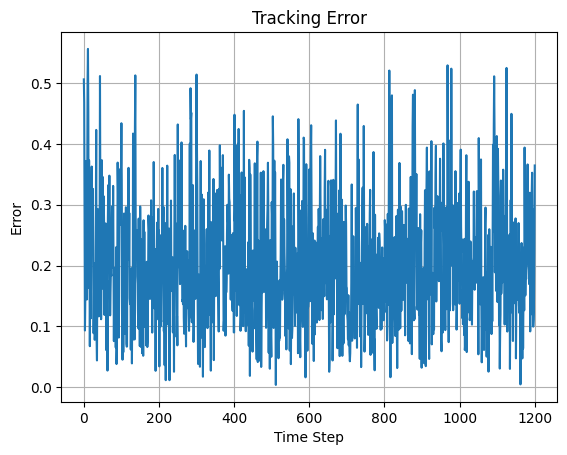

2 sigma (95.45%): 0.3977
3 sigma (99.73%): 0.5228


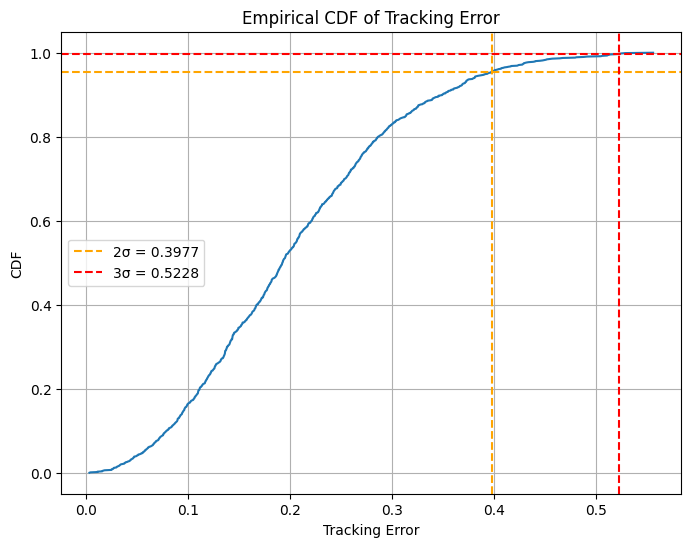

In [16]:
import numpy as np
import json
import os

local_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
cal_report_dir = local_dir + '/output/calibration_report.json'

with open(cal_report_dir, 'r') as f:
    calibration_report = json.load(f)

s_ref = [calibration_report['Sensor_0']['x'], calibration_report['Sensor_0']['y']]
s_1 = [calibration_report['Sensor_1']['x'], calibration_report['Sensor_1']['y']]
s_2 = [calibration_report['Sensor_2']['x'], calibration_report['Sensor_2']['y']]
s_3 = [calibration_report['Sensor_3']['x'], calibration_report['Sensor_3']['y']]

sref_toa = np.array(calibration_report['Sensor_0']['toa'])
s1_tdoa = np.array(calibration_report['Sensor_1']['toa']) - sref_toa
s2_tdoa = np.array(calibration_report['Sensor_2']['toa']) - sref_toa
s3_tdoa = np.array(calibration_report['Sensor_3']['toa']) - sref_toa

sref_var = calibration_report['Sensor_0']['pp_std'] ** 2
s1_var = calibration_report['Sensor_1']['pp_std'] ** 2
s2_var = calibration_report['Sensor_2']['pp_std'] ** 2
s3_var = calibration_report['Sensor_3']['pp_std'] ** 2

R = np.array([[s1_var + sref_var, sref_var, sref_var],
              [sref_var, s2_var + sref_var, sref_var],
              [sref_var, sref_var, s3_var + sref_var]])


state = np.array([[calibration_report['target_location'][0]['x'], 0.0, 0.0,
                   calibration_report['target_location'][0]['y'], 0.0, 0.0]]).T


ekf = SINGER_EKF(state, R, tau=0.5)
ekf.s_ref = s_ref
ekf.s_1 = s_1
ekf.s_2 = s_2
ekf.s_3 = s_3
ekf.c = 343.0

plt.figure()
plt.plot(state[0], state[3], 'ro')
pos_track = [[state[0], state[3]]]

for dt_s1, dt_s2, dt_s3 in zip(s1_tdoa, s2_tdoa, s3_tdoa):

    #predict
    ekf.predict(dt=0.5)

    Y = np.array([[dt_s1, dt_s2, dt_s3]]).T
    ekf.update(Y)

    state = ekf.get_state()

    pos_track.append([state[0], state[3]])
    plt.plot(state[0], state[3], 'ro', alpha=0.5)

plt.axis('equal')
plt.title('EKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array([0.0, 0.0])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()

In [37]:
P = np.array([[2,0],[0,2]])
L = np.linalg.cholesky(P)
P, L, L[:,0], L[:,1]

x = [1,2,3]
w = [0,0,0]

from scipy.linalg import block_diag

M = block_diag(P, L)

np.concatenate((x, w))

array([1, 2, 3, 0, 0, 0])